# Step 1: Classical bits in a quantum problem

## Import modules

In [2]:
# Built-in modules
import math

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution

# Imports from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [4]:
# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
backend.name

'ibm_marrakesh'

In [10]:
def grover_oracle(marked_states):
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])

    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bit-string to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bit-string
        zero_inds = [
            ind
            for ind in range(num_qubits)
            if rev_target.startswith("0", ind)
        ]
        # Add a multi-controlled Z-gate with pre- and post-applied X-gates (open-controls)
        # where the target bit-string has a '0' entry
        if zero_inds:
            qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)
    return qc

## Specific Grover's instance


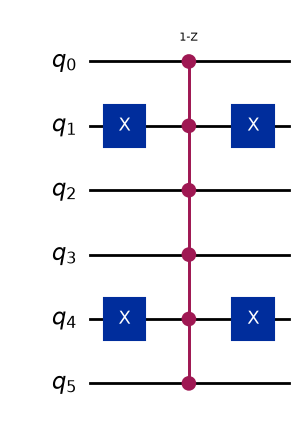

In [11]:
# marked_states = ["10110", "11001"]
marked_states = ["101101"]

oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")

## Grover operator
Qiskit has built-in grover operator. Here we decompose it to see the individual gates.

/tmp/ipykernel_1132/2665495518.py:1: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover_op = GroverOperator(oracle)


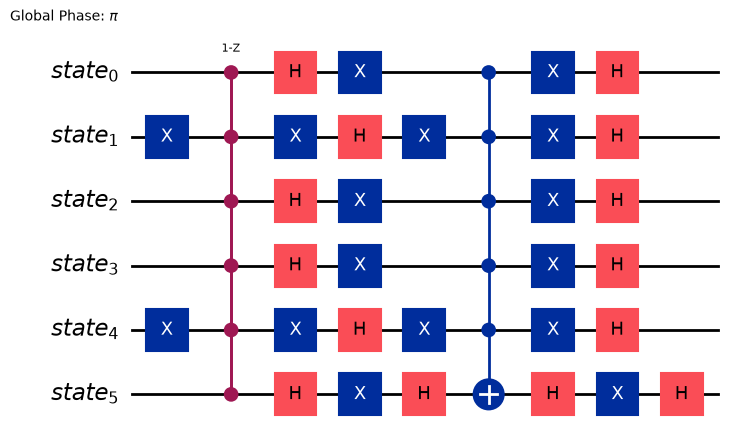

In [12]:
grover_op = GroverOperator(oracle)
grover_op.decompose().draw(output="mpl", style="iqp")

## Amplifying marked states
There is an optimal number of such applications that is determined by the ratio of marked states to total number of possible computational states

In [13]:
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

## Full circuit

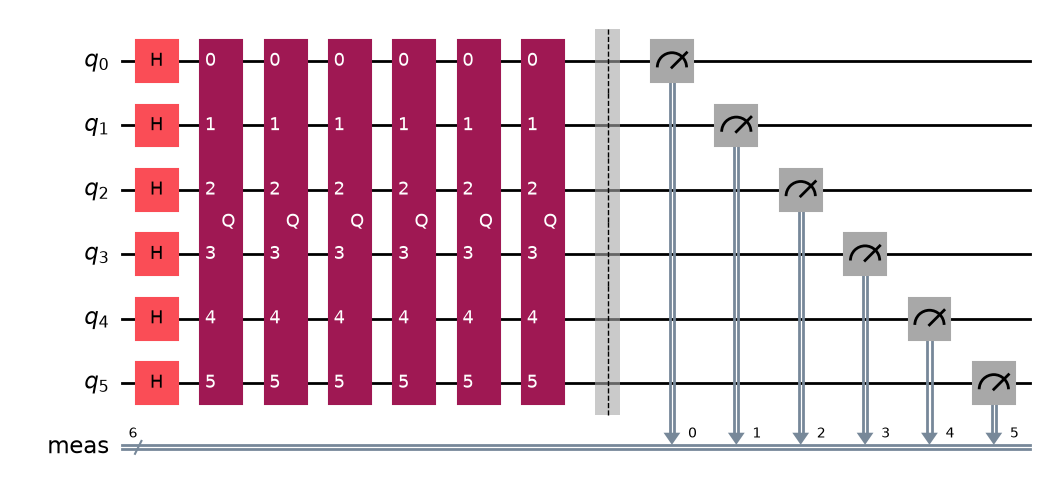

In [14]:
qc = QuantumCircuit(grover_op.num_qubits)
# Create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl", style="iqp")

In [16]:
qc.depth()

8

# Step 2: Optimize

In [15]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3, layout_method="sabre", routing_method="sabre")

circuit_isa = pm.run(qc)
# circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")

sampler = Sampler(mode=backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.dynamical_decoupling.extra_slack_distribution = "middle"

sampler.options.default_shots = 100_000

sampler.options.twirling.enable_gates = True
sampler.options.twirling.enable_measure = True

In [17]:
circuit_isa.depth()

5500

# Step 3: Execute using primitives

In [9]:
job = sampler.run([circuit_isa])
job_id = job.job_id()

# Step 4: Post process
We return the result in a classical format

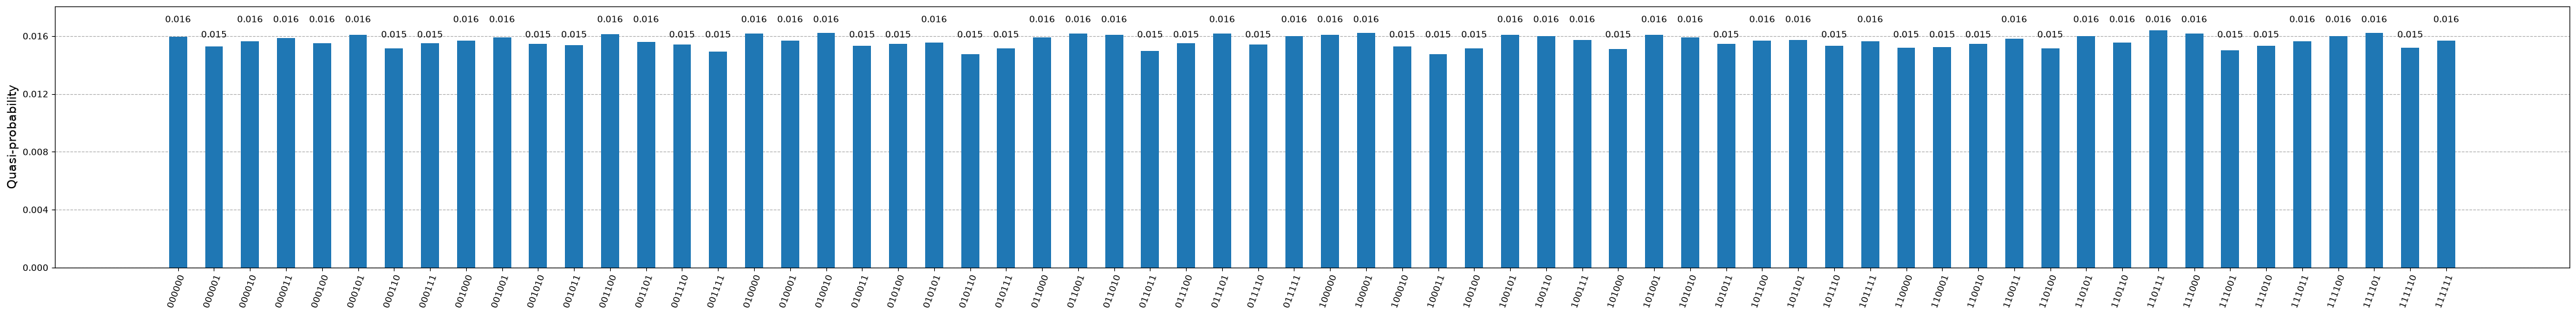

In [9]:
result = service.job("d967o9if47jc73a58c4g").result()
dist = result[0].data.meas.get_counts()
plot_distribution(dist, figsize=(40, 5))